<a href="https://colab.research.google.com/github/MiguelUTEC26/Parcia04_Miguel_Angel_Diaz_Lopez_25-4356-2019/blob/main/Correlacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from itertools import combinations
df = pd.read_csv("https://raw.githubusercontent.com/MiguelUTEC26/Parcia04_Miguel_Angel_Diaz_Lopez_25-4356-2019/refs/heads/main/data/raw/clave_F_correlacion.csv")

In [5]:
print(df.head())
print(df.shape)
print(df.info())


  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    F-C0001    18                1184                  6            63.55   
1    F-C0002    32                1023                  8            60.06   
2    F-C0003    46                1231                  9            61.11   
3    F-C0004    48                 783                  4            37.37   
4    F-C0005    31                1187                  7            65.26   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          7.05         1        2             20.42         344.76  
1          7.88         2        7             12.99         475.57  
2          7.22         1        5             23.16         554.42  
3          5.69         4        4             26.98         233.89  
4          3.50         8        7             28.48         386.42  
(246, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 10 column

In [9]:
df = df.fillna(0)

In [10]:
df.duplicated().sum()

df.isnull().sum()

,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,0
satisfaccion,0
reclamos,0
uso_app,0
tiempo_respuesta,0
consumo_total,0


In [6]:
print(df.shape)

(246, 10)


In [20]:
media = df[columna].mean()
desviacion = df[columna].std()

limite_inferior = media - 2 * desviacion
limite_superior = media + 2 * desviacion

variables_numericas = [
    "edad",
    "ingresos_mensuales",
    "frecuencia_compra",
    "ticket_promedio",
    "satisfaccion",
    "reclamos"
]

for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(columna,",",media,",",desviacion,",",limite_inferior,"," ,limite_superior,",", len(atipicos))



edad , 38.796747967479675 , 10.220395255421229 , 18.355957456637217 , 59.237538478322136 , 10
ingresos_mensuales , 1117.60162601626 , 265.00669964076036 , 587.5882267347394 , 1647.615025297781 , 13
frecuencia_compra , 7.90650406504065 , 3.2881044682097555 , 1.330295128621139 , 14.482713001460162 , 3
ticket_promedio , 65.90264227642277 , 16.029099861740026 , 33.844442552942716 , 97.96084199990281 , 10
satisfaccion , 7.498943089430894 , 1.4212074848927987 , 4.656528119645297 , 10.341358059216493 , 8
reclamos , 1.5365853658536586 , 1.7486679848542859 , -1.9607506038549132 , 5.03392133556223 , 8


In [25]:
matriz_correlacion = df.corr(numeric_only=True)
matriz_correlacion.round(3)


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.000,0.070,0.074,0.134,-0.013,0.046,0.062,0.002,0.097
ingresos_mensuales,0.070,1.000,0.066,0.629,-0.026,0.006,-0.045,0.179,0.323
frecuencia_compra,0.074,0.066,1.000,0.163,0.158,-0.069,0.401,-0.073,0.896
ticket_promedio,0.134,0.629,0.163,1.000,-0.011,0.007,-0.009,0.094,0.503
satisfaccion,-0.013,-0.026,0.158,-0.011,1.000,-0.774,0.277,-0.560,0.205
reclamos,0.046,0.006,-0.069,0.007,-0.774,1.000,-0.021,0.608,-0.141
uso_app,0.062,-0.045,0.401,-0.009,0.277,-0.021,1.000,-0.207,0.393
tiempo_respuesta,0.002,0.179,-0.073,0.094,-0.560,0.608,-0.207,1.000,-0.100
consumo_total,0.097,0.323,0.896,0.503,0.205,-0.141,0.393,-0.100,1.000


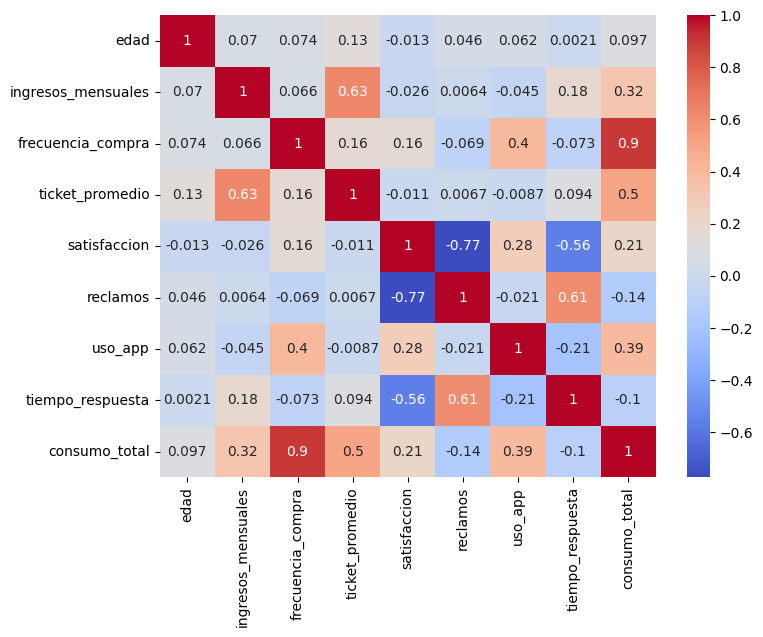

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm")
plt.show()

In [24]:
matriz_correlacion[abs(matriz_correlacion) > 0.7]

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
edad,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ingresos_mensuales,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frecuencia_compra,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,NaN,0.89613
ticket_promedio,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
satisfaccion,NaN,NaN,NaN,NaN,1.000000,-0.773521,NaN,NaN,NaN
reclamos,NaN,NaN,NaN,NaN,-0.773521,1.000000,NaN,NaN,NaN
uso_app,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
tiempo_respuesta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
consumo_total,NaN,NaN,0.89613,NaN,NaN,NaN,NaN,NaN,1.00000


In [26]:
matriz_correlacion = df.corr()

ValueError: could not convert string to float: 'F-C0001'